# Historical Transactions — Cleanup & Feature Prep

Produce two clean, versioned artifacts under `trndly/data/processed/`:

- **`transactions.parquet`** — `df_transactions`, a fact table with `date`, `article_id`, `price`, and 7 minted `*_id` feature columns.
- **`lookup.csv`** — `df_lookup`, a long-format decode table mapping `(category, id) -> name`.

No aggregation, windowing, or target construction happens here — that belongs in the next stage of the pipeline. This notebook stops at clean, typed, numeric training inputs.

---

## Final outputs (current run)

### `df_transactions` — fact table

- **shape:** 30,444,049 rows × 10 cols
- **on disk:** ~215 MB (parquet, default zstd) · **in memory:** ~700 MB (every minted `*_id` is `int8`; `article_id` is `int32`)
- **date coverage:** 2018-09-20 → 2020-09-22 (734 consecutive days, no gaps)
- **price:** float32, normalized 0–1 in source data; p50 = 0.0254, p99 = 0.1017, max = 0.5915
- **explicit nulls:** 0 in every column

Per-column summary (non-null in every cell; "unknown" counts are decoded sentinel values, not missing data):

| column | dtype | distinct (incl. Unknown) | unknown rows | unknown % | notes |
|---|---|---:|---:|---:|---|
| `date` | datetime64[ns] | 734 | — | — | 1 day = 1 unique value |
| `article_id` | int32 | 69,449 | — | — | raw H&M article id; carried through for downstream catalog-share aggregation |
| `price` | float32 | 9,857 | — | — | normalized; no exact zeros, 158 rows > 0.5 |
| `product_type_id` | int8 | 95 | — | — | no Unknown bucket; ids 1..95 freq-ranked |
| `product_group_id` | int8 | 9 | — | — | `Unknown` group blacklisted upstream; ids 1..9 |
| `graphical_appearance_id` | int8 | 27 | 859,408 | 2.82% | id 0 = Unknown (includes `Other structure`, `Other pattern`, `Application/3D`); ids 1..26 freq-ranked |
| `color_master_id` | int8 | 14 | 288,281 | 0.95% | id 0 = Unknown; rare masters merged pre-mint (e.g. Khaki green/Yellowish Green→Green, Turquoise/Bluish Green→Blue, Mole→Brown, Lilac Purple→Purple); ids 1..13 |
| `color_spectrum_id` | int8 | 7 | 25,888 | 0.09% | id 0 = Unknown (`Undefined` folded in); spectrum from `perceived_colour_value_name` (Dark, Dusty Light, etc.); ids 1..6 |
| `gender_id` | int8 | 3 | — | — | Women / Men / Unisex (section 10 renames H&M `Ladieswear` / `Menswear` / `Divided` after Sport + baby cut); ids 1..3 |
| `material_id` | int8 | 35 | 6,085,210 | 19.99% | minted from `detail_desc` regex + `garment_group_name` fallback; id 0 = Unknown; ids 1..34 |

### `df_lookup` — dimension table

- **shape:** 190 rows × 3 cols (one `(category, 0, 'Unknown')` row for every column that has Unknown rows)
- **columns:** `category` (str), `id` (int16), `name` (str) — one row per `(category, id)` pair
- **categories** (rows per category, including Unknown where applicable): `product_type` 95 · `material` 35 · `graphical_appearance` 27 · `color_master` 14 · `product_group` 9 · `color_spectrum` 7 · `gender` 3

### How to use

```python
import pandas as pd
tx = pd.read_parquet('trndly/data/processed/transactions.parquet')
lk = pd.read_csv('trndly/data/reference/lookup.csv')

# Decode any *_id column by joining lk filtered to the matching category:
mat = lk[lk['category'] == 'material'][['id', 'name']]
tx_decoded = tx.merge(mat, left_on='material_id', right_on='id', how='left') \
               .rename(columns={'name': 'material_name'}) \
               .drop(columns='id')
```

### Provenance & attrition

| stage | rows | delta |
|---|---:|---:|
| raw `transactions_train.csv` | 31,788,324 | — |
| after Sport reclassification + baby/children cut | 30,554,641 | −1,233,683 |
| after rare/Unknown `product_group` cut | 30,444,049 | −110,592 |
| → `df_transactions` | **30,444,049** | **95.77% of raw retained** |

Inputs (read but not all consumed):
- `transactions_train.csv` — 31.8M × 5 — used
- `articles.csv` — 105,542 × 25 — used
- `customers.csv` — 1.37M × 7 — **not used** (out of scope for this stage)

### Known caveats

- **`material_id == 0` ("Unknown")** covers 19.99% of rows (6.08M) by construction. Most come from H&M descriptions that say "woven fabric" / "soft weave" without naming a fiber, plus heterogeneous accessories. Treated as a real categorical level (id 0). Future upgrade path: description embeddings (`detail_desc` → sentence transformer) — see followups.
- **Color sentinels were collapsed pre-mint.** `perceived_colour_value_name` "Undefined" and `perceived_colour_master_name` "undefined" were renamed to `Unknown` before minting. Additional **color master** merges (section 10): Khaki green and Yellowish Green→Green, Mole→Brown, Lilac Purple→Purple, Bluish Green and Turquoise→Blue. **Graphical:** `Other structure`, `Other pattern`, and `Application/3D` share id 0 with Unknown. **Gender:** H&M `Ladieswear` / `Menswear` / `Divided`→Women / Men / Unisex after Sport. Fine-grained `colour_group_name` is not minted; `garment_group` is not persisted.

---

## Contents

1. Setup
2. Load data
3. Merge
4. Column shortlist
5. Audit `_no` / `_name` pair integrity
6. Normalize off-pairs
7. Target schema
8. Reclassify Sport + cut baby products
9. Cut rare product groups
10. Pre-mint name cleanup
11. Discover material vocabulary
12. Extract `material_name`
13. Mint all categorical IDs
14. Build `df_lookup`
15. Apply final schema → `df_transactions`
16. Sanity checks
17. Persist outputs
18. Validation (visual)

## Convention

A single rolling working frame `df` is used across sections 4–13. It is renamed and retyped into `df_transactions` exactly once in section 15.

Every categorical `*_id` column follows the same rule:

- `0` = `Unknown` (only present in columns that have an Unknown bucket).
- `1..N` = real categories, ranked by descending transaction frequency (most-common = 1).

This means every minted `*_id` fits in `int8`. The lone exception is `article_id`, which is the *raw* H&M id (not minted, not in the lookup) carried through as `int32` so downstream aggregation notebooks can compute distinct-article counts without re-loading the raw CSV.

H&M-native ID ranges (`-1`, `1001..`, `1010001..`) are dropped during minting; their `(id → name)` mappings live only in the rebuilt `df_lookup`.


## 1. Setup


In [3]:
import os
import re
import gc
from collections import Counter

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 200)

DATA_DIR = '../data/raw/kaggle'
OUT_DIR  = '../data/processed'
REFERENCE_DIR = '../data/reference'

# Columns we carry from transactions_full into the working frame df.
# Keeps both `_no` and `_name` siblings so the pair audit + normalization in
# section 5/6 can inspect them. Schema is narrowed to final feature columns
# in section 14.
KEEP_COLUMNS = [
    't_dat', 'article_id', 'price',
    'product_code', 'prod_name',
    'product_type_no', 'product_type_name',
    'product_group_name',
    'graphical_appearance_no', 'graphical_appearance_name',
    'colour_group_code', 'colour_group_name',
    'perceived_colour_value_id', 'perceived_colour_value_name',
    'perceived_colour_master_id', 'perceived_colour_master_name',
    'department_no', 'department_name',
    'index_code', 'index_name',
    'index_group_no', 'index_group_name',
    'section_no', 'section_name',
    'garment_group_no', 'garment_group_name',
]

# Rare-tail cutoff for product_group_name, measured in articles.csv rows.
PRODUCT_GROUP_MIN_ARTICLES = 100

# Material vocabulary. Initial list is seeded from the probes in section 11;
# revise this list after inspecting the probe output and re-run from section 12.
# Order matters: compound terms first so `imitation leather` is matched before
# `leather`. Frequent fibers are ranked above rarer ones so blends like
# "cotton and wool" resolve to the likely-dominant fiber.
MATERIAL_PATTERNS = [
    # compound terms first so `imitation leather` is matched before `leather`
    ('imitation leather', r'\bimitation leather\b'),
    ('imitation suede',   r'\bimitation suede\b'),
    ('faux fur',          r'\bfaux fur\b'),
    # H&M's catalog uses "sweatshirt fabric" almost exclusively for cotton-blend
    # fleeceback knits; folding it into cotton avoids a redundant bucket.
    ('cotton',            r'\bsweatshirt fabric\b'),
    # specific hides / high-signal fibers
    ('cashmere',          r'\bcashmere\b'),
    ('shearling',         r'\bshearling\b'),
    ('leather',           r'\bleather\b'),
    ('suede',             r'\bsuede\b'),
    ('denim',             r'\bdenim\b'),
    ('wool',              r'\bwool\b'),
    ('silk',              r'\bsilk\b'),
    ('linen',             r'\blinen\b'),
    # specific fabric constructions
    ('corduroy',          r'\bcorduroy\b'),
    ('velvet',            r'\bvelvet\b'),
    ('velour',            r'\bvelour\b'),
    ('fleece',            r'\bfleece\b'),
    ('tulle',             r'\btulle\b'),
    ('satin',             r'\bsatin\b'),
    ('canvas',            r'\bcanvas\b'),
    ('chiffon',           r'\bchiffon\b'),
    ('crepe',             r'\bcr\u00eape\b|\bcrepe\b'),
    ('twill',             r'\btwill\b'),
    ('lace',              r'\blace\b'),
    ('mesh',              r'\bmesh\b'),
    # common fibers
    ('cotton',            r'\bcotton\b'),
    ('polyester',         r'\bpolyester\b'),
    ('viscose',           r'\bviscose\b'),
    ('nylon',             r'\bnylon\b'),
    ('acrylic',           r'\bacrylic\b'),
    ('modal',             r'\bmodal\b'),
    ('lyocell',           r'\blyocell\b'),
    ('tencel',            r'\btencel\b'),
    ('elastane',          r'\belastane\b'),
    ('spandex',           r'\bspandex\b'),
    # generic fabric-construction catch-alls, last so specific fibers win first
    ('jersey',            r'\bjersey\b'),
    ('knit',              r'\bknit\b'),
    ('metal',             r'\bmetal\b'),
]

# Fallback: if `detail_desc` yields no material match, infer from
# `garment_group_name`. Only unambiguous groups.
GARMENT_GROUP_FALLBACK = {
    'Jersey Fancy': 'jersey',
    'Jersey Basic': 'jersey',
    'Knitwear':     'knit',
}

# product_group_name values to drop regardless of article count. These are
# data-entry placeholders (every row also has product_type_name='Unknown'),
# not a real category.
UNKNOWN_PRODUCT_GROUPS = {'Unknown'}

# Sport is a style, not a gender. `section_name` disambiguates. Used in
# section 8 to reassign Sport rows to the right gender before the baby cut.
SPORT_TO_GENDER = {
    'Ladies H&M Sport': (1, 'Ladieswear'),
    'Men H&M Sport':    (3, 'Menswear'),
    'Kids Sports':      (4, 'Baby/Children'),
}


## 2. Load data

`customers.csv` is out of scope for this project (no customer-level modeling), so we only load transactions and the article dimension table.


In [4]:
transactions = pd.read_csv(f'{DATA_DIR}/transactions_train.csv')
articles     = pd.read_csv(f'{DATA_DIR}/articles.csv')

print(f'transactions: {transactions.shape[0]:,} rows x {transactions.shape[1]} cols')
print(f'articles:     {articles.shape[0]:,} rows x {articles.shape[1]} cols')


transactions: 31,788,324 rows x 5 cols
articles:     105,542 rows x 25 cols


## 3. Merge


In [5]:
df_raw = transactions.merge(articles, on='article_id', how='left')
print(f'df_raw: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols')


df_raw: 31,788,324 rows x 29 cols


## 4. Column shortlist

Drop everything we will not need downstream (customer_id, sales_channel_id, detail_desc once extracted in section 12). Everything from here to section 14 operates on the single rolling frame `df`.


In [6]:
df = df_raw[KEEP_COLUMNS].copy()
del df_raw, transactions
gc.collect()
print(f'df: {df.shape[0]:,} rows x {df.shape[1]} cols')
df.head()

df: 31,788,324 rows x 26 cols


,t_dat,article_id,price,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name
0,2018-09-20,663713001,0.050831,663713,Atlanta Push Body Harlow,283,Underwear body,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1338,Expressive Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"
1,2018-09-20,541518023,0.030492,541518,Rae Push (Melbourne) 2p,306,Bra,Underwear,1010016,Solid,51,Light Pink,1,Dusty Light,4,Pink,1334,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear"
2,2018-09-20,505221004,0.015237,505221,Inca Jumper,252,Sweater,Garment Upper body,1010010,Melange,52,Pink,2,Medium Dusty,4,Pink,5963,Tops Knitwear DS,D,Divided,2,Divided,58,Divided Selected,1003,Knitwear
3,2018-09-20,685687003,0.016932,685687,W YODA KNIT OL OFFER,252,Sweater,Garment Upper body,1010010,Melange,52,Pink,7,Medium,4,Pink,3090,Campaigns,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1023,Special Offers
4,2018-09-20,685687004,0.016932,685687,W YODA KNIT OL OFFER,252,Sweater,Garment Upper body,1010010,Melange,93,Dark Green,4,Dark,19,Green,3090,Campaigns,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1023,Special Offers


## 5. Audit `_no` / `_name` pair integrity

Each `_no` column should map 1:1 to its `_name` twin. Where it does not, we must normalize before the name can be used as a stable label. This cell identifies the off-pairs.


In [7]:
PAIRS = [
    ('product_code',                'prod_name'),
    ('product_type_no',             'product_type_name'),
    ('graphical_appearance_no',     'graphical_appearance_name'),
    ('colour_group_code',           'colour_group_name'),
    ('perceived_colour_value_id',   'perceived_colour_value_name'),
    ('perceived_colour_master_id',  'perceived_colour_master_name'),
    ('department_no',               'department_name'),
    ('index_code',                  'index_name'),
    ('index_group_no',              'index_group_name'),
    ('section_no',                  'section_name'),
    ('garment_group_no',            'garment_group_name'),
]


def find_off_pairs(frame, pairs):
    off = []
    for left, right in pairs:
        vl = np.sort(frame[left].value_counts().to_numpy())
        vr = np.sort(frame[right].value_counts().to_numpy())
        if not np.array_equal(vl, vr):
            off.append((left, right))
    return off


OFF_PAIRS = find_off_pairs(df, PAIRS)
print('off-pairs detected:')
for a, b in OFF_PAIRS:
    print(f'  {a} <-> {b}')

off-pairs detected:
  product_code <-> prod_name
  product_type_no <-> product_type_name
  department_no <-> department_name
  section_no <-> section_name


## 6. Normalize off-pairs

For every (group_col, value_col) off-pair, collapse duplicate values to the most prevalent one per group. Apply bidirectionally so that both columns end up mutually consistent. Re-audit at the end to confirm all 11 pairs are now 1:1.


In [8]:
def normalize_to_most_prevalent(frame, group_col, value_col):
    pair_counts = (
        frame.groupby([group_col, value_col], dropna=False)
             .size()
             .reset_index(name='row_count')
    )
    pair_counts['_tie_break'] = pair_counts[value_col].astype(str)

    canonical = (
        pair_counts.sort_values(
            [group_col, 'row_count', '_tie_break'],
            ascending=[True, False, True],
            kind='mergesort',
        )
        .drop_duplicates(subset=[group_col], keep='first')
        [[group_col, value_col]]
        .rename(columns={value_col: f'canonical_{value_col}'})
    )

    option_counts = (
        pair_counts.groupby(group_col, dropna=False)[value_col]
                   .nunique(dropna=False)
                   .rename('n_options')
                   .reset_index()
    )
    ambiguous = option_counts[option_counts['n_options'] > 1][[group_col]]
    update_map = (
        ambiguous.merge(canonical, on=group_col, how='left')
                 .set_index(group_col)[f'canonical_{value_col}']
    )

    mask = frame[group_col].isin(update_map.index)
    original = frame.loc[mask, value_col].copy()
    frame.loc[mask, value_col] = frame.loc[mask, group_col].map(update_map)
    changed = int((original != frame.loc[mask, value_col]).sum())
    return len(update_map), changed

In [9]:
for left, right in OFF_PAIRS:
    for group_col, value_col in [(left, right), (right, left)]:
        n_groups, n_changed = normalize_to_most_prevalent(df, group_col, value_col)
        print(f'{group_col:30s} -> {value_col:30s}  groups={n_groups:<6d}  rows_changed={n_changed:,}')


product_code                   -> prod_name                       groups=2165    rows_changed=1,827,847
prod_name                      -> product_code                    groups=2866    rows_changed=1,121,361
product_type_no                -> product_type_name               groups=0       rows_changed=0
product_type_name              -> product_type_no                 groups=1       rows_changed=2,111
department_no                  -> department_name                 groups=0       rows_changed=0
department_name                -> department_no                   groups=22      rows_changed=4,344,790
section_no                     -> section_name                    groups=0       rows_changed=0
section_name                   -> section_no                      groups=1       rows_changed=434


In [10]:
remaining = find_off_pairs(df, PAIRS)
assert not remaining, f'unexpected off-pairs after normalization: {remaining}'
print('all 11 pairs are now 1:1')

all 11 pairs are now 1:1


## 7. Target schema

Before moving into lookup splitting and aggregation, define what we want the two output tables to look like. Every step from here on serves these schemas.

### Unified ID convention

Every categorical `*_id` column follows the same rule:

- `0` = `Unknown` (only present in columns that have an Unknown bucket).
- `1..N` = real categories, ranked by descending transaction frequency (most-common = 1).

All H&M-native ID ranges (`-1`, `1001..`, `1010001..`) are dropped during minting; their `(id → name)` mappings live only in the rebuilt `df_lookup`. Compact ranges mean every `*_id` fits in `int8`.

### `df_transactions` — fact table (row per purchase line)

All feature columns are integer IDs. Human-readable strings live only in the lookup table.

| column | dtype | minted from | purpose |
|---|---|---|---|
| `date` | datetime64 | `t_dat` | time axis for aggregation |
| `price` | float32 | `price` | signal / optional feature |
| `product_type_id` | int8 | `product_type_name` | specific product type (no Unknown bucket) |
| `product_group_id` | int8 | `product_group_name` | broader product group (Unknown blacklisted upstream) |
| `graphical_appearance_id` | int8 | `graphical_appearance_name` | pattern / design (`0` = Unknown, plus `Other structure`, `Other pattern`, `Application/3D` bucketed to Unknown at mint) |
| `color_master_id` | int8 | `perceived_colour_master_name` | master color (`0` = Unknown; `undefined` + merges in section 10 before mint) |
| `color_spectrum_id` | int8 | `perceived_colour_value_name` | spectrum: Dark, Dusty Light, etc. (`0` = Unknown; `Undefined` folded in) |
| `gender_id` | int8 | `index_group_name` | Women / Men / Unisex (section 10 renames H&M labels after Sport reclassification + baby/children cut) |
| `material_id` | int8 | `material_name` (extracted in section 12) | material (`0` = Unknown) |

**Note on `material_id`:** H&M's `articles.csv` has no material column. We derive a `material_name` string from `detail_desc` (section 12) and then mint it into `material_id` in the unified step alongside every other categorical (section 13).

### Dropped before aggregation

`customer_id`, `article_id`, `sales_channel_id`, `product_code` / `prod_name` (too granular), `department_*`, `index_code` / `index_name`, `section_*` (H&M-internal org), `detail_desc` (consumed by material extraction, then dropped), and all `_name` twins (they move to the lookup table).

### `df_lookup` — decode table (long format)

One row per `(category, id)` pair. Single file, single append to add a new dimension.

| column | dtype | purpose |
|---|---|---|
| `category` | str | `product_type`, `product_group`, `graphical_appearance`, `color_master`, `color_spectrum`, `gender`, `material` |
| `id` | int | numeric ID used in `df_transactions` |
| `name` | str | human-readable label |


## 8. Reclassify Sport + cut baby products

Two steps, in order:

1. **Reclassify Sport articles by `section_name`** into the correct H&M gender index (`Ladieswear`, `Menswear`, or `Baby/Children` for kids). Sport is a style, not a gender — the section-name column disambiguates cleanly. This also closes a leak where `Kids Sports` articles currently survive the baby filter because their `index_group_name` is `Sport`, not `Baby/Children`.
2. **Cut baby/children** rows as before.

After this section, `index_group_name` is only `Ladieswear`, `Divided`, or `Menswear` on the surviving rows. **Section 10** renames those strings to **Women**, **Unisex**, and **Men** before minting into `gender_id`.


In [11]:
sport_mask = df['index_group_name'] == 'Sport'
before = int(sport_mask.sum())

for section, (gno, gname) in SPORT_TO_GENDER.items():
    m = sport_mask & (df['section_name'] == section)
    df.loc[m, 'index_group_no']   = gno
    df.loc[m, 'index_group_name'] = gname

residual = int((df['index_group_name'] == 'Sport').sum())
assert residual == 0, f'{residual:,} Sport rows still present after reclassification'
print(f'reclassified {before:,} Sport rows by section_name')
print(df.loc[sport_mask, 'index_group_name'].value_counts())


reclassified 1,246,408 Sport rows by section_name
index_group_name
Ladieswear       1177490
Menswear           52584
Baby/Children      16334
Name: count, dtype: int64


In [12]:
before = len(df)
df = df[df['index_group_name'] != 'Baby/Children'].copy()
print(f'dropped {before - len(df):,} baby/children rows, {len(df):,} remain')


dropped 1,233,683 baby/children rows, 30,554,641 remain


## 9. Cut rare product groups

Two cuts:

1. **Rare-tail groups** with fewer than `PRODUCT_GROUP_MIN_ARTICLES` in `articles.csv` (e.g. `Furniture`, `Stationery`, `Fun`). Data-driven cutoff, not a hard-coded list.
2. **`Unknown` product group** (explicit blacklist in `UNKNOWN_PRODUCT_GROUPS`). Every article in this bucket also has `product_type_name='Unknown'` — it's a data-entry placeholder, not a real category. The ~100 articles (~97k transactions) survive the rare-tail threshold but contribute noise, not signal.


In [13]:
article_group_counts = articles['product_group_name'].value_counts()
keep_groups = (
    set(article_group_counts[article_group_counts >= PRODUCT_GROUP_MIN_ARTICLES].index)
    - UNKNOWN_PRODUCT_GROUPS
)

dropped_by_count = sorted(
    article_group_counts[article_group_counts < PRODUCT_GROUP_MIN_ARTICLES].index
)
dropped_by_blacklist = sorted(
    UNKNOWN_PRODUCT_GROUPS & set(article_group_counts.index)
)

print(f'keeping {len(keep_groups)} product groups:')
for g in sorted(keep_groups):
    print(f'  {g} ({article_group_counts[g]:,} articles)')
print(f'dropping {len(dropped_by_count)} rare-tail groups (< {PRODUCT_GROUP_MIN_ARTICLES} articles): {dropped_by_count}')
print(f'dropping {len(dropped_by_blacklist)} blacklisted groups: {dropped_by_blacklist}')

before = len(df)
df = df[df['product_group_name'].isin(keep_groups)].copy()
print(f'dropped {before - len(df):,} rows, {len(df):,} remain')


keeping 9 product groups:
  Accessories (11,158 articles)
  Garment Full body (13,292 articles)
  Garment Lower body (19,812 articles)
  Garment Upper body (42,741 articles)
  Nightwear (1,899 articles)
  Shoes (5,283 articles)
  Socks & Tights (2,442 articles)
  Swimwear (3,127 articles)
  Underwear (5,490 articles)
dropping 9 rare-tail groups (< 100 articles): ['Bags', 'Cosmetic', 'Fun', 'Furniture', 'Garment and Shoe care', 'Interior textile', 'Items', 'Stationery', 'Underwear/nightwear']
dropping 1 blacklisted groups: ['Unknown']
dropped 110,592 rows, 30,444,049 remain


## 10. Pre-mint name cleanup

Before minting, normalize string values on `df` so minting sees stable labels.

**Sentinels & internal consistency**

1. `colour_group_name`: `Other` → `Unknown` (not minted to disk; subsumed by `color_master`).
2. `perceived_colour_value_name` (feeds `color_spectrum_id`): `Undefined` → `Unknown`.
3. `perceived_colour_master_name` (feeds `color_master_id`): `undefined` → `Unknown`.

**Color master merges** (same column): Khaki green & Yellowish Green → `Green`; Mole → `Brown`; Lilac Purple → `Purple`; Bluish Green & Turquoise → `Blue`.

**Gender display names** (`index_group_name`): `Ladieswear` → `Women`, `Menswear` → `Men`, `Divided` → `Unisex`.

**Graphical** (`graphical_appearance_name`): `Other structure`, `Other pattern`, and `Application/3D` are *not* renamed here; they are passed to minting as extra `unknown_names` so they share id `0` with `Unknown`.

`product_type_name` is intentionally left alone. The `_no` siblings are not touched — minting re-derives every ID from the `_name` columns.


In [14]:
RENAMES = [
    ('colour_group_name',            'Other',     'Unknown'),
    ('perceived_colour_value_name',  'Undefined', 'Unknown'),
    ('perceived_colour_master_name', 'undefined', 'Unknown'),
    # Color master: collapse rare H&M master labels into canonical buckets
    ('perceived_colour_master_name', 'Khaki green',     'Green'),
    ('perceived_colour_master_name', 'Mole',            'Brown'),
    ('perceived_colour_master_name', 'Lilac Purple',    'Purple'),
    ('perceived_colour_master_name', 'Yellowish Green', 'Green'),
    ('perceived_colour_master_name', 'Bluish Green',    'Blue'),
    ('perceived_colour_master_name', 'Turquoise',       'Blue'),
    # Gender: display names (Sport reclassification still uses H&M labels upstream)
    ('index_group_name', 'Ladieswear', 'Women'),
    ('index_group_name', 'Menswear',    'Men'),
    ('index_group_name', 'Divided',     'Unisex'),
]

for col, old, new in RENAMES:
    n_renamed = int((df[col] == old).sum())
    df.loc[df[col] == old, col] = new
    n_unknown_total = int((df[col] == new).sum())
    print(
        f'  {col:<32}  renamed {n_renamed:>10,} {old!r} -> {new!r}'
        f'  (Unknown total: {n_unknown_total:,} = {n_unknown_total / len(df) * 100:.2f}%)'
    )


  colour_group_name                 renamed     20,293 'Other' -> 'Unknown'  (Unknown total: 25,888 = 0.09%)
  perceived_colour_value_name       renamed     20,293 'Undefined' -> 'Unknown'  (Unknown total: 25,888 = 0.09%)
  perceived_colour_master_name      renamed     20,293 'undefined' -> 'Unknown'  (Unknown total: 288,281 = 0.95%)
  perceived_colour_master_name      renamed    859,121 'Khaki green' -> 'Green'  (Unknown total: 1,764,984 = 5.80%)
  perceived_colour_master_name      renamed    325,771 'Mole' -> 'Brown'  (Unknown total: 933,876 = 3.07%)
  perceived_colour_master_name      renamed    190,597 'Lilac Purple' -> 'Purple'  (Unknown total: 190,597 = 0.63%)
  perceived_colour_master_name      renamed        930 'Yellowish Green' -> 'Green'  (Unknown total: 1,765,914 = 5.80%)
  perceived_colour_master_name      renamed        165 'Bluish Green' -> 'Blue'  (Unknown total: 3,853,490 = 12.66%)
  perceived_colour_master_name      renamed    204,296 'Turquoise' -> 'Blue'  (Unknown t

## 11. Discover material vocabulary

`detail_desc` is free-form English. Rather than invent a material list, we probe the actual text three ways:

- **Probe A** — count how often each seeded candidate word appears, to surface zero-hit seeds and get true frequencies.
- **Probe B** — unigram frequency across all descriptions, filtered by a small stop-list and a minimum length, to catch any material word the seeds miss.
- **Probe C** — bigram frequency, to catch compound materials (`imitation leather`, `organic cotton`, `recycled polyester`).

After reviewing the probe outputs, revise `MATERIAL_PATTERNS` in section 1 if needed, then re-run from section 12.


In [15]:
# Probe A — seeded candidate hit counts
SEED_CANDIDATES = [
    'cotton', 'wool', 'silk', 'linen', 'cashmere', 'mohair',
    'polyester', 'viscose', 'rayon', 'nylon', 'acrylic',
    'elastane', 'spandex', 'modal', 'lyocell', 'tencel',
    'leather', 'suede', 'imitation leather', 'imitation suede',
    'faux fur', 'fur',
    'denim',
]
desc_lower = articles['detail_desc'].fillna('').str.lower()
hit_counts = {
    s: int(desc_lower.str.contains(rf'\b{re.escape(s)}\b', regex=True).sum())
    for s in SEED_CANDIDATES
}
pd.Series(hit_counts, name='articles_with_term').sort_values(ascending=False)


cotton               33459
viscose               6334
denim                 5507
leather               5121
imitation leather     4235
wool                  2989
polyester             2766
suede                 1824
linen                 1396
fur                   1374
imitation suede       1342
faux fur              1327
lyocell                760
tencel                 760
silk                   677
cashmere               643
modal                  592
nylon                  351
mohair                 164
acrylic                  9
elastane                 6
rayon                    1
spandex                  0
Name: articles_with_term, dtype: int64

In [16]:
# Probe B — unigram top-100
STOP_WORDS = set('''a an and the in of with at on for to from by made contain contains
has have is are this that these those short long fine soft warm airy also slightly
sleeves sleeve neckline hem waist pocket pockets zip button fastening front back side
regular high low round square wide narrow small large medium top bottom'''.split())

token_counts = Counter()
for t in desc_lower:
    for w in re.findall(r"[a-z][a-z\-]+", t):
        if len(w) >= 4 and w not in STOP_WORDS:
            token_counts[w] += 1
pd.Series(dict(token_counts.most_common(100)), name='unigram_freq')


cotton          34230
jersey          27309
cuffs           23652
elasticated     19442
fabric          18931
                ...  
welt             3280
hook-and-eye     3260
wrapover         3239
flared           3168
gathered         3152
Name: unigram_freq, Length: 100, dtype: int64

In [17]:
# Probe C — bigram top-75
bigram_counts = Counter()
for t in desc_lower:
    toks = re.findall(r"[a-z][a-z\-]+", t)
    for a, b in zip(toks, toks[1:]):
        bigram_counts[f'{a} {b}'] += 1
pd.Series(dict(bigram_counts.most_common(75)), name='bigram_freq')


at the                 79573
in soft                28860
the back               24478
the front              24337
jersey with            16939
                       ...  
longer at               4298
back of                 4284
drawstring waist        4279
cotton weave            4234
adjustable shoulder     4112
Name: bigram_freq, Length: 75, dtype: int64

## 12. Extract `material_name`

Run the curated `MATERIAL_PATTERNS` (from section 1) on `articles.detail_desc` once, then join the per-article `material_name` onto `df`. First-match-wins; unmatched descriptions become `Unknown` (matching the Unknown sentinel name used in every other categorical column — so the unified minting step in section 13 can treat material exactly like the rest).

Running regex on ~105k articles is much cheaper than on ~30M transactions.

The actual `material_id` minting moves out of this section into the unified step in section 13.


In [18]:
def extract_material_from_desc(text):
    """First pass: regex-scan `detail_desc` for a material keyword."""
    if not isinstance(text, str):
        return None
    low = text.lower()
    for name, pat in MATERIAL_PATTERNS:
        if re.search(pat, low):
            return name
    return None


# Two-pass: description first (fiber signal), garment_group fallback when
# description is silent (e.g. "Weekend sweat" has no fabric word but its
# garment_group_name is "Jersey Fancy").
articles_mat = articles[['article_id', 'detail_desc', 'garment_group_name']].copy()
articles_mat['material_name'] = articles_mat['detail_desc'].map(extract_material_from_desc)

missing_mask = articles_mat['material_name'].isna()
fallback     = articles_mat.loc[missing_mask, 'garment_group_name'].map(GARMENT_GROUP_FALLBACK)
articles_mat.loc[missing_mask, 'material_name'] = fallback
articles_mat['material_name'] = articles_mat['material_name'].fillna('Unknown')

n_total    = len(articles_mat)
n_by_desc  = int((~missing_mask).sum())
n_by_group = int(fallback.notna().sum())
n_unknown  = int((articles_mat['material_name'] == 'Unknown').sum())
print('material resolution on articles:')
print(f'  by detail_desc:         {n_by_desc:,}  ({n_by_desc / n_total * 100:.1f}%)')
print(f'  by garment_group_name:  {n_by_group:,}  ({n_by_group / n_total * 100:.1f}%)')
print(f'  unknown:                {n_unknown:,}  ({n_unknown / n_total * 100:.1f}%)')
print()
print('material_name distribution on articles:')
print(articles_mat['material_name'].value_counts())


material resolution on articles:
  by detail_desc:         88,957  (84.3%)
  by garment_group_name:  2,058  (1.9%)
  unknown:                14,527  (13.8%)

material_name distribution on articles:
material_name
cotton               32029
Unknown              14527
jersey                8505
denim                 5449
viscose               4856
lace                  4583
imitation leather     4235
knit                  4005
metal                 3465
twill                 3449
wool                  2777
mesh                  2206
crepe                 1986
satin                 1656
linen                 1372
polyester             1190
faux fur              1099
chiffon               1011
fleece                 994
leather                872
imitation suede        772
silk                   668
cashmere               635
canvas                 526
velour                 513
tulle                  494
corduroy               486
lyocell                289
nylon                  202
suede

In [19]:
df = df.merge(
    articles_mat[['article_id', 'material_name']],
    on='article_id', how='left',
)
df['material_name'] = df['material_name'].fillna('Unknown')
print('material_name distribution on df:')
print(df['material_name'].value_counts(dropna=False))


material_name distribution on df:
material_name
Unknown              6085210
cotton               4989810
jersey               3431326
denim                2535029
lace                 2309651
viscose              2127904
knit                 1410119
metal                1048239
crepe                 925358
wool                  914491
twill                 796866
imitation leather     793768
linen                 539142
mesh                  478092
satin                 445870
polyester             441099
chiffon               272376
faux fur              117090
leather               113925
velour                 89774
imitation suede        86192
lyocell                80222
fleece                 64743
modal                  59300
canvas                 56963
corduroy               56142
silk                   48377
cashmere               47728
nylon                  21178
suede                  19880
velvet                 17858
shearling              10932
tulle                   

## 13. Mint all categorical IDs

Single unified step that produces every `*_id` feature column **and** assembles the per-category lookup rows. Convention applied uniformly:

- `id = 0` → `Unknown` (only emitted when the column has any Unknown rows).
- `id = 1..N` → real categories, ranked by descending transaction frequency (most-common = 1).

The helper takes a name column and an optional set of names to fold into Unknown. Real categories are frequency-ranked from `df` directly, so a re-run on the same data is deterministic. All H&M-native ID ranges (`-1`, `1001..`, `1010001..`) are dropped; their (id → name) mappings live only in the rebuilt lookup table.

Bonus: every `*_id` column ends up with `max <= ~95`, so each one fits in `int8`. Memory drops ~30% on the fact table.


In [20]:
def mint_id_column(df, name_col, category, unknown_names=()):
    """Mint a frequency-ranked compact id column.

    - Names in `unknown_names` (any number of variants) all map to id 0
      and produce a single canonical `(category, 0, 'Unknown')` lookup row.
    - Real categories get ids 1..N ranked by descending transaction frequency.

    Returns:
        id_series : int8 Series aligned to df
        lk_rows   : DataFrame with columns [category, id, name]
    """
    is_unk = df[name_col].isin(unknown_names) if unknown_names else pd.Series(False, index=df.index)
    real_counts = df.loc[~is_unk, name_col].value_counts()  # descending
    name_to_id = {n: i + 1 for i, n in enumerate(real_counts.index)}

    lk_rows = [(category, i, n) for n, i in name_to_id.items()]
    if is_unk.any():
        for u in unknown_names:
            name_to_id[u] = 0
        lk_rows = [(category, 0, 'Unknown')] + lk_rows

    new_col = df[name_col].map(name_to_id).astype('int8')
    return new_col, pd.DataFrame(lk_rows, columns=['category', 'id', 'name'])


# (name_col, category, unknown_names)
MINT_SPECS = [
    ('product_type_name',            'product_type',         ()),
    ('product_group_name',           'product_group',        ()),
    ('graphical_appearance_name',    'graphical_appearance', (
        'Unknown',
        'Other structure',
        'Other pattern',
        'Application/3D',
    )),
    ('perceived_colour_master_name', 'color_master',         ('Unknown',)),
    ('perceived_colour_value_name',  'color_spectrum',       ('Unknown',)),
    ('index_group_name',             'gender',               ()),
    ('material_name',                'material',             ('Unknown',)),
]

lookup_parts = []
print(f'{"category":<22}  {"ids":<10}  {"real":>5}  {"unk_rows":>12}  {"unk_%":>6}')
print(f'{"-"*22}  {"-"*10}  {"-"*5}  {"-"*12}  {"-"*6}')
for name_col, category, unknown_names in MINT_SPECS:
    id_col = f'{category}_id'
    df[id_col], lk_part = mint_id_column(df, name_col, category, unknown_names)
    lookup_parts.append(lk_part)

    n_unk = int((df[id_col] == 0).sum()) if unknown_names else 0
    n_real = int(df[id_col].max())
    id_lo = int(df[id_col].min())
    id_hi = int(df[id_col].max())
    pct = n_unk / len(df) * 100
    print(f'{category:<22}  {id_lo}..{id_hi:<7}  {n_real:>5}  {n_unk:>12,}  {pct:>5.2f}%')


category                ids          real      unk_rows   unk_%
----------------------  ----------  -----  ------------  ------
product_type            1..95          95             0   0.00%
product_group           1..9            9             0   0.00%
graphical_appearance    0..26          26       859,408   2.82%
color_master            0..13          13       288,281   0.95%
color_spectrum          0..6            6        25,888   0.09%
gender                  1..3            3             0   0.00%
material                0..34          34     6,085,210  19.99%


## 14. Build `df_lookup`

Long-format decode table. The unified minting step in section 13 already produced one `(category, id, name)` DataFrame per dimension; here we just concatenate them and sort.


In [21]:
df_lookup = (
    pd.concat(lookup_parts, ignore_index=True)
      .sort_values(['category', 'id'], ignore_index=True)
)
df_lookup['id']   = df_lookup['id'].astype('int16')
df_lookup['name'] = df_lookup['name'].astype(str)

print(f'df_lookup: {len(df_lookup):,} rows  ({df_lookup["category"].nunique()} categories)')
df_lookup


df_lookup: 190 rows  (7 categories)


,category,id,name
0,color_master,0,Unknown
1,color_master,1,Black
2,color_master,2,Blue
3,color_master,3,White
4,color_master,4,Beige
...,...,...,...
185,product_type,91,Long John
186,product_type,92,Bootie
187,product_type,93,Headband
188,product_type,94,Giftbox


## 15. Apply final schema -> `df_transactions`

Select the minted `*_id` columns (already in the working frame from section 13), rename `t_dat`, cast every id to `int8`. Single reassignment so there is no drift risk. After this cell `df` can be discarded.


In [22]:
final_cols = [
    'date', 'article_id', 'price',
    'product_type_id', 'product_group_id',
    'graphical_appearance_id',
    'color_master_id', 'color_spectrum_id',
    'gender_id',
    'material_id',
]

# Every minted *_id is a frequency-ranked compact int in [0, ~95] -> int8.
# article_id is the raw H&M article id (max ~10 digits) -> int32 covers it.
minted_id_cols = [c for c in final_cols if c.endswith('_id') and c != 'article_id']
dtype_map = {
    'price': 'float32',
    'article_id': 'int32',
    **{c: 'int8' for c in minted_id_cols},
}

df_transactions = (
    df.rename(columns={'t_dat': 'date'})
      .assign(date=lambda d: pd.to_datetime(d['date']))
      [final_cols]
      .astype(dtype_map)
      .reset_index(drop=True)
)

del df
gc.collect()

df_transactions.head()


,date,article_id,price,product_type_id,product_group_id,graphical_appearance_id,color_master_id,color_spectrum_id,gender_id,material_id
0,2018-09-20,663713001,0.050831,38,5,1,1,1,1,4
1,2018-09-20,541518023,0.030492,8,5,1,8,2,1,4
2,2018-09-20,505221004,0.015237,3,1,4,8,4,2,1
3,2018-09-20,685687003,0.016932,3,1,4,8,5,1,0
4,2018-09-20,685687004,0.016932,3,1,4,5,1,1,0


## 16. Sanity checks


In [23]:
print('shape:', df_transactions.shape)
print()
print('dtypes:')
print(df_transactions.dtypes)
print()
print('null counts (expect 0 everywhere):')
print(df_transactions.isna().sum())
print()
print('memory (MB):', round(df_transactions.memory_usage(deep=True).sum() / 1e6, 1))
print()
print('date range:', df_transactions['date'].min(), '->', df_transactions['date'].max())


shape: (30444049, 10)

dtypes:
date                       datetime64[ns]
article_id                          int32
price                             float32
product_type_id                      int8
product_group_id                     int8
graphical_appearance_id              int8
color_master_id                      int8
color_spectrum_id                    int8
gender_id                            int8
material_id                          int8
dtype: object

null counts (expect 0 everywhere):
date                       0
article_id                 0
price                      0
product_type_id            0
product_group_id           0
graphical_appearance_id    0
color_master_id            0
color_spectrum_id          0
gender_id                  0
material_id                0
dtype: int64

memory (MB): 700.2

date range: 2018-09-20 00:00:00 -> 2020-09-22 00:00:00


In [24]:
print('lookup rows per category:')
print(df_lookup.groupby('category').size().sort_values(ascending=False))
print()
print('lookup dtypes:')
print(df_lookup.dtypes)
print()

# Convention asserts: id == 0 <=> name == 'Unknown' (within a category)
print('Unknown / id=0 invariant:')
print(f'{"category":<22}  {"unk_rows":>8}  {"id0_rows":>8}  {"status":<6}')
print('-' * 50)
all_ok = True
for cat, sub in df_lookup.groupby('category'):
    n_unk = int((sub['name'] == 'Unknown').sum())
    n_id0 = int((sub['id'] == 0).sum())
    ok = (n_unk == n_id0) and (n_unk <= 1)
    # Stronger: when there is an Unknown row, it must sit at id=0
    if n_unk == 1:
        ok = ok and bool((sub.loc[sub['name'] == 'Unknown', 'id'] == 0).all())
    flag = 'OK' if ok else 'FAIL'
    if not ok:
        all_ok = False
    print(f'{cat:<22}  {n_unk:>8}  {n_id0:>8}  {flag:<6}')
print()
print(f'Unknown invariant: {"PASS" if all_ok else "FAIL"}')
print()

# id range matches lookup row count (max id in df == n_rows - 1 if Unknown present, else n_rows)
ID_TO_CATEGORY = {
    'product_type_id':         'product_type',
    'product_group_id':        'product_group',
    'graphical_appearance_id': 'graphical_appearance',
    'color_master_id':         'color_master',
    'color_spectrum_id':       'color_spectrum',
    'gender_id':               'gender',
    'material_id':             'material',
}
print('id range vs lookup row count:')
print(f'{"id column":<26}  {"range":<12}  {"n_lk":>5}  {"unk":>4}  {"status":<6}')
print('-' * 60)
range_ok = True
for id_col, cat in ID_TO_CATEGORY.items():
    sub = df_lookup[df_lookup['category'] == cat]
    n_lk = len(sub)
    has_unknown = bool((sub['name'] == 'Unknown').any())
    expected_max = n_lk - 1 if has_unknown else n_lk
    expected_min = 0 if has_unknown else 1
    actual_min = int(df_transactions[id_col].min())
    actual_max = int(df_transactions[id_col].max())
    ok = (actual_min == expected_min) and (actual_max == expected_max)
    if not ok:
        range_ok = False
    flag = 'OK' if ok else 'FAIL'
    print(f'{id_col:<26}  [{actual_min},{actual_max}]   {n_lk:>5}  {str(has_unknown):>4}  {flag:<6}')
print()
print(f'Range invariant: {"PASS" if range_ok else "FAIL"}')
print()
print('first 15 lookup rows:')
df_lookup.head(15)


lookup rows per category:
category
product_type            95
material                35
graphical_appearance    27
color_master            14
product_group            9
color_spectrum           7
gender                   3
dtype: int64

lookup dtypes:
category    object
id           int16
name        object
dtype: object

Unknown / id=0 invariant:
category                unk_rows  id0_rows  status
--------------------------------------------------
color_master                   1         1  OK    
color_spectrum                 1         1  OK    
gender                         0         0  OK    
graphical_appearance           1         1  OK    
material                       1         1  OK    
product_group                  0         0  OK    
product_type                   0         0  OK    

Unknown invariant: PASS

id range vs lookup row count:
id column                   range          n_lk   unk  status
------------------------------------------------------------
product_typ

,category,id,name
0,color_master,0,Unknown
1,color_master,1,Black
2,color_master,2,Blue
3,color_master,3,White
4,color_master,4,Beige
5,color_master,5,Green
6,color_master,6,Grey
7,color_master,7,Red
8,color_master,8,Pink
9,color_master,9,Brown


## 17. Persist outputs

`trndly/data/processed/` is gitignored. These artifacts are regenerated by restart-and-run-all on this notebook.


In [25]:
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(REFERENCE_DIR, exist_ok=True)

tx_path     = f'{OUT_DIR}/transactions.parquet'
lookup_path = f'{REFERENCE_DIR}/lookup.csv'

df_transactions.to_parquet(tx_path, index=False)
df_lookup.to_csv(lookup_path, index=False)

print(f'wrote {tx_path}  ({os.path.getsize(tx_path) / 1e6:.1f} MB)')
print(f'wrote {lookup_path}  ({os.path.getsize(lookup_path) / 1e3:.1f} KB)')


wrote ../data/processed/transactions.parquet  (214.9 MB)
wrote ../data/processed/lookup.csv  (4.8 KB)


## 18. Validation (visual)

Read the persisted artifacts back from disk and eyeball them. Every chart below should match an expectation; if one looks off, the pipeline is wrong, not the chart.

Checks:

- **Attrition accounting** — how many rows survived each cut, as a percentage of the raw transactions.
- **Time coverage** — weekly transaction counts across the full date span. Should be continuous, with visible seasonality.
- **Price distribution** — should be right-skewed, positive, no absurd outliers.
- **Per-dimension row counts** — the specific concern about rare-tail cuts is answered here (`product_group_id`, `gender_id`, `material_id`).
- **Decode spot-check** — join a random sample against `df_lookup` to confirm IDs resolve to sensible names.


In [26]:
tx = pd.read_parquet(f'{OUT_DIR}/transactions.parquet')
lk = pd.read_csv(f'{REFERENCE_DIR}/lookup.csv')

print(f'df_transactions: {tx.shape[0]:,} rows x {tx.shape[1]} cols')
print(f'df_lookup:       {lk.shape[0]:,} rows')


def decode(series, category):
    """Map an id Series to its human-readable name via df_lookup."""
    m = dict(zip(
        lk.loc[lk['category'] == category, 'id'],
        lk.loc[lk['category'] == category, 'name'],
    ))
    return series.map(m)


df_transactions: 30,444,049 rows x 10 cols
df_lookup:       190 rows


In [27]:
with open(f'{DATA_DIR}/transactions_train.csv') as f:
    raw_tx_count = sum(1 for _ in f) - 1

kept = len(tx)
dropped = raw_tx_count - kept
print(f'raw transactions:    {raw_tx_count:,}')
print(f'kept (df_transactions): {kept:,}  ({kept / raw_tx_count * 100:.1f}%)')
print(f'dropped total:          {dropped:,}  ({dropped / raw_tx_count * 100:.1f}%)')
print()
print('attrition comes from two cuts:')
print('  - baby/children rows (section 8)')
print('  - rare product_group_name tails, < 100 articles each (section 9)')


raw transactions:    31,788,324
kept (df_transactions): 30,444,049  (95.8%)
dropped total:          1,344,275  (4.2%)

attrition comes from two cuts:
  - baby/children rows (section 8)
  - rare product_group_name tails, < 100 articles each (section 9)


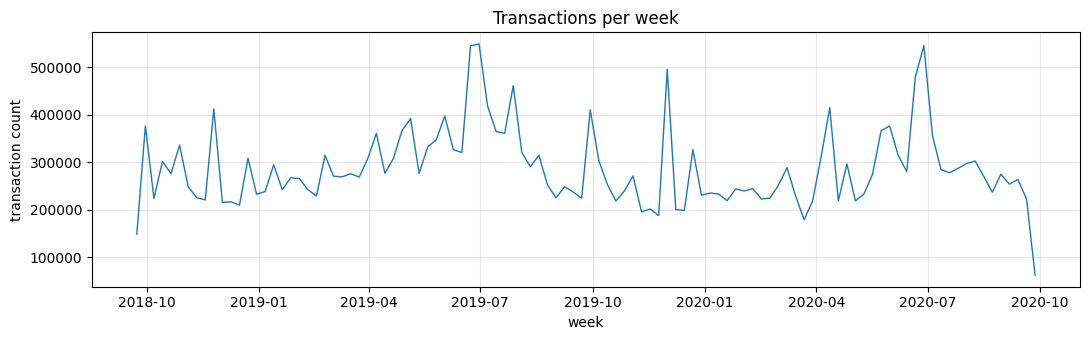

date range: 2018-09-20 -> 2020-09-22
weeks covered: 106
empty weeks:   0


In [28]:
import matplotlib.pyplot as plt

weekly = (
    tx.set_index('date')
      .assign(n=1)['n']
      .resample('W')
      .sum()
)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(weekly.index, weekly.values, linewidth=1)
ax.set_title('Transactions per week')
ax.set_xlabel('week')
ax.set_ylabel('transaction count')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f'date range: {tx["date"].min().date()} -> {tx["date"].max().date()}')
print(f'weeks covered: {len(weekly)}')
print(f'empty weeks:   {int((weekly == 0).sum())}')


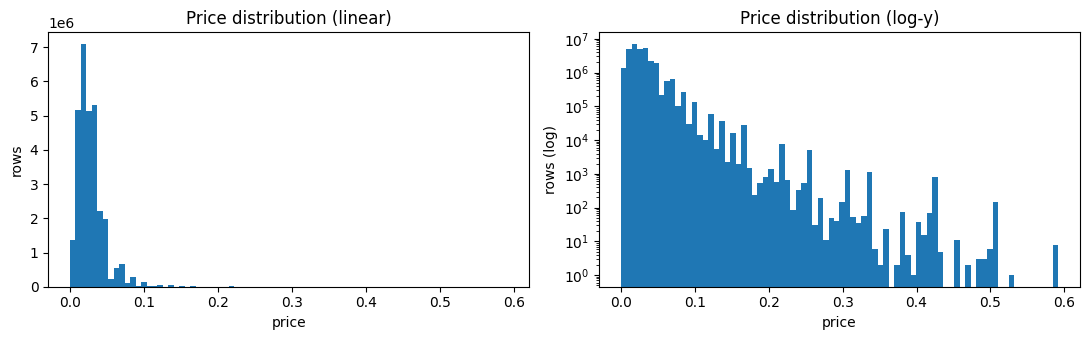

count    3.044405e+07
mean     2.817896e-02
std      1.860863e-02
min      1.694915e-05
1%       3.796610e-03
5%       7.898306e-03
50%      2.540678e-02
95%      6.100000e-02
99%      1.016780e-01
max      5.915254e-01
Name: price, dtype: float64


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(tx['price'], bins=80)
axes[0].set_title('Price distribution (linear)')
axes[0].set_xlabel('price')
axes[0].set_ylabel('rows')

axes[1].hist(tx['price'], bins=80)
axes[1].set_yscale('log')
axes[1].set_title('Price distribution (log-y)')
axes[1].set_xlabel('price')
axes[1].set_ylabel('rows (log)')

fig.tight_layout()
plt.show()

print(tx['price'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


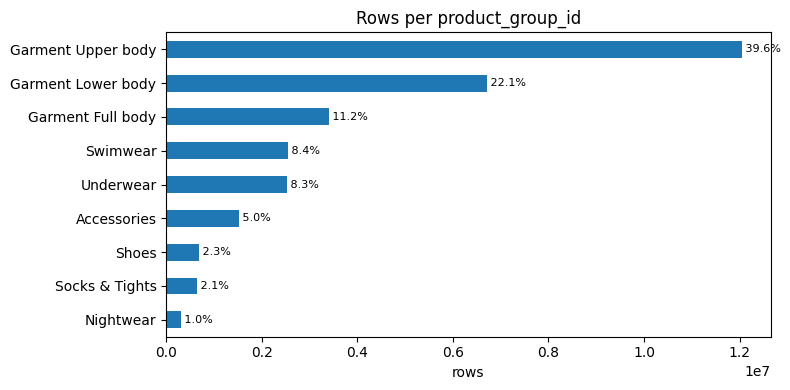

Garment Upper body    12049206
Garment Lower body     6715266
Garment Full body      3408636
Swimwear               2556191
Underwear              2529488
Accessories            1530955
Shoes                   694818
Socks & Tights          642361
Nightwear               317128
Name: count, dtype: int64


In [30]:
pg_counts = tx['product_group_id'].value_counts().sort_index()
pg_counts.index = decode(pg_counts.index.to_series(), 'product_group').values

fig, ax = plt.subplots(figsize=(8, 4))
pg_counts.sort_values().plot.barh(ax=ax)
ax.set_title('Rows per product_group_id')
ax.set_xlabel('rows')
for i, v in enumerate(pg_counts.sort_values().values):
    ax.text(v, i, f' {v / len(tx) * 100:.1f}%', va='center', fontsize=8)
fig.tight_layout()
plt.show()

print(pg_counts.sort_values(ascending=False))


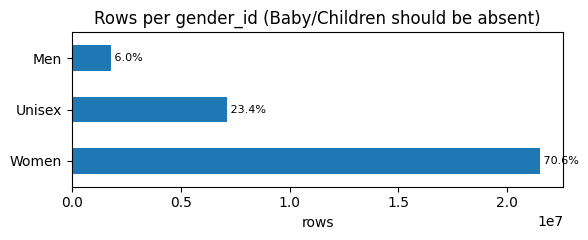

Women     21504296
Unisex     7126736
Men        1813017
Name: count, dtype: int64

baby/children confirmed absent


In [31]:
gender_counts = tx['gender_id'].value_counts().sort_values(ascending=False)
gender_counts.index = decode(gender_counts.index.to_series(), 'gender').values

fig, ax = plt.subplots(figsize=(6, 2.5))
gender_counts.plot.barh(ax=ax)
ax.set_title('Rows per gender_id (Baby/Children should be absent)')
ax.set_xlabel('rows')
for i, v in enumerate(gender_counts.values):
    ax.text(v, i, f' {v / len(tx) * 100:.1f}%', va='center', fontsize=8)
fig.tight_layout()
plt.show()

print(gender_counts)
assert 'Baby/Children' not in gender_counts.index, 'baby rows leaked through!'
print('\nbaby/children confirmed absent')


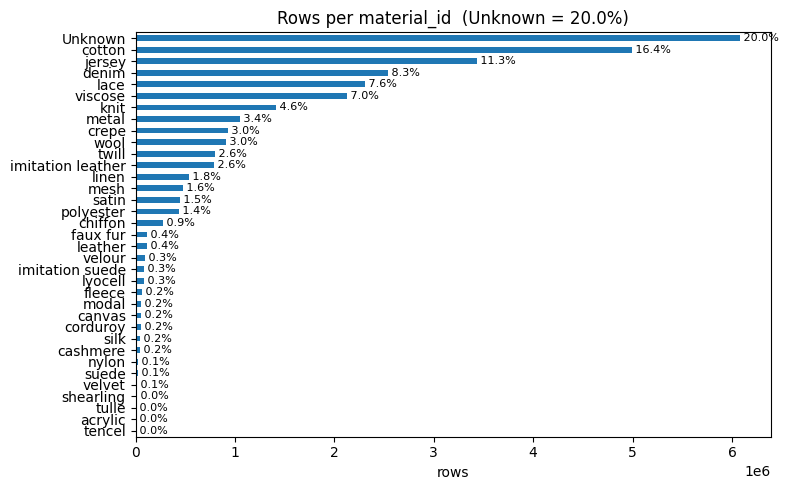

Unknown              6085210
cotton               4989810
jersey               3431326
denim                2535029
lace                 2309651
viscose              2127904
knit                 1410119
metal                1048239
crepe                 925358
wool                  914491
twill                 796866
imitation leather     793768
linen                 539142
mesh                  478092
satin                 445870
polyester             441099
chiffon               272376
faux fur              117090
leather               113925
velour                 89774
imitation suede        86192
lyocell                80222
fleece                 64743
modal                  59300
canvas                 56963
corduroy               56142
silk                   48377
cashmere               47728
nylon                  21178
suede                  19880
velvet                 17858
shearling              10932
tulle                   8758
acrylic                  627
tencel        

In [32]:
mat_counts = tx['material_id'].value_counts().sort_values(ascending=False)
mat_counts.index = decode(mat_counts.index.to_series(), 'material').values
unknown_share = mat_counts.get('Unknown', 0) / len(tx) * 100

fig, ax = plt.subplots(figsize=(8, 5))
mat_counts.sort_values().plot.barh(ax=ax)
ax.set_title(f'Rows per material_id  (Unknown = {unknown_share:.1f}%)')
ax.set_xlabel('rows')
for i, v in enumerate(mat_counts.sort_values().values):
    ax.text(v, i, f' {v / len(tx) * 100:.1f}%', va='center', fontsize=8)
fig.tight_layout()
plt.show()

print(mat_counts)
if unknown_share > 20:
    print(f'\nWARNING: {unknown_share:.1f}% unknown is high. Review section 11 probes and extend MATERIAL_PATTERNS.')


In [33]:
ID_TO_CATEGORY = {
    'product_type_id':         'product_type',
    'product_group_id':        'product_group',
    'graphical_appearance_id': 'graphical_appearance',
    'color_master_id':         'color_master',
    'color_spectrum_id':       'color_spectrum',
    'gender_id':               'gender',
    'material_id':             'material',
}

summary_rows = []
for id_col, cat in ID_TO_CATEGORY.items():
    vc = tx[id_col].value_counts()
    top_id = vc.index[0]
    top_name = decode(pd.Series([top_id]), cat).iloc[0]
    summary_rows.append({
        'dimension': cat,
        'n_categories_in_lookup': int((lk['category'] == cat).sum()),
        'n_categories_in_tx':     int(vc.shape[0]),
        'top_name':               top_name,
        'top_share_%':            round(vc.iloc[0] / len(tx) * 100, 1),
    })

pd.DataFrame(summary_rows).set_index('dimension')


,n_categories_in_lookup,n_categories_in_tx,top_name,top_share_%
dimension,,,,
product_type,95,95,Trousers,13.2
product_group,9,9,Garment Upper body,39.6
graphical_appearance,27,27,Solid,57.0
color_master,14,14,Black,35.2
color_spectrum,7,7,Dark,49.5
gender,3,3,Women,70.6
material,35,35,Unknown,20.0


In [34]:
sample = tx.sample(10, random_state=7).reset_index(drop=True)
decoded = sample.copy()
for id_col, cat in ID_TO_CATEGORY.items():
    decoded[id_col.replace('_id', '')] = decode(sample[id_col], cat)

show_cols = ['date', 'price'] + [c.replace('_id', '') for c in ID_TO_CATEGORY]
decoded[show_cols]

decoded = decoded[show_cols]